# PRECISION, RECALL, F1 SCORE, PROBABILITY, AND THRESHOLD TUNING

# DATA MANIPULATION, DATA VIZUALIZATION, AND MACHINE LEARNING & PREPROCESSING

In [506]:
# DATA MANIPULATION
import pandas as pd
import numpy as np
import os 

# DATA VIZUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# MACHINE LEARNING & PREPROCESSING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from pathlib import Path

# LOADED DATASET

In [507]:
DATA_PATH = Path('healthcare-dataset-stroke-data.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(f'{DATA_PATH} not found')
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
print(f'LOADED DATA: {df.shape}')


LOADED DATA: (5110, 12)


In [508]:
# Initial data inspection 
print('--- Dataset Shape ---')
print(df.shape)

# Display First 5 Rows 
print('\n --- First 5 Rows ---')
display(df.head())

# Data Information 
print('\n --- Data Information ---')
print(df.info())

--- Dataset Shape ---
(5110, 12)

 --- First 5 Rows ---


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



 --- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None


In [509]:
df.nunique()

id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64

# FEATURE ENGINEERING 

In [510]:
# Drop unnecassary for prediction 
df.drop(columns=['id', 'gender'], errors='igoner', inplace=True)


In [511]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                5110 non-null   float64
 1   hypertension       5110 non-null   int64  
 2   heart_disease      5110 non-null   int64  
 3   ever_married       5110 non-null   object 
 4   work_type          5110 non-null   object 
 5   Residence_type     5110 non-null   object 
 6   avg_glucose_level  5110 non-null   float64
 7   bmi                4909 non-null   float64
 8   smoking_status     5110 non-null   object 
 9   stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 399.3+ KB


# DATA PREPROCESSING 

In [512]:
class DataPreprocessing:
    def __init__(self, df):
        self.df = df
    
    # Handling Missing Values
    def miss_vals(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if self.df[col].dtype == 'object':
                    self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
                else:
                    self.df[col] = self.df[col].fillna(self.df[col].median())
        return self 
    
    # Encoding: from categorical to numercial as to translate into machine-readable language
    def encodla(self):
        le = LabelEncoder()
        cat_cols = self.df.select_dtypes(include=['object']).columns
        for col in cat_cols :
            self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
            self.df[col] = le.fit_transform(self.df[col].astype(str))
        return self
    
    # Scaling: Transforming numerical features into a common range (like 0 to 1)
    def scaling(self):
        scaler = MinMaxScaler()
        cat_cols = self.df.select_dtypes(include=np.number).columns.drop('stroke')
        self.df[cat_cols] = scaler.fit_transform(self.df[cat_cols])
        return self
    
processor = DataPreprocessing(df)
df_ready = (
    processor
    .miss_vals()
    .encodla()
    .scaling()
    .df
)
print(f"Data after Preprocessing: {df_ready.shape}")
        




Data after Preprocessing: (5110, 10)


In [513]:
df_ready.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                5110 non-null   float64
 1   hypertension       5110 non-null   float64
 2   heart_disease      5110 non-null   float64
 3   ever_married       5110 non-null   float64
 4   work_type          5110 non-null   float64
 5   Residence_type     5110 non-null   float64
 6   avg_glucose_level  5110 non-null   float64
 7   bmi                5110 non-null   float64
 8   smoking_status     5110 non-null   float64
 9   stroke             5110 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 399.3 KB


In [514]:
df = df_ready

# TRANSFORM FEATURES

In [515]:
num_cols = df.select_dtypes(include=np.number)
skewness = num_cols.skew()

# Log transformation skewness >= 0.5
log_transformation = skewness[(skewness>=0.5)].index.tolist()
print(f"The columns of the log transformation: ", log_transformation)


The columns of the log transformation:  ['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']


In [516]:
log_cols = [
    'hypertension', 
    'heart_disease', 
    'avg_glucose_level', 
    'bmi'
]
for col in log_cols:
    df[col + '_log'] = np.log1p(df[col])
df = df.drop(log_cols, axis=1)

In [517]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5110 non-null   float64
 1   ever_married           5110 non-null   float64
 2   work_type              5110 non-null   float64
 3   Residence_type         5110 non-null   float64
 4   smoking_status         5110 non-null   float64
 5   stroke                 5110 non-null   int64  
 6   hypertension_log       5110 non-null   float64
 7   heart_disease_log      5110 non-null   float64
 8   avg_glucose_level_log  5110 non-null   float64
 9   bmi_log                5110 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 399.3 KB


In [518]:
df['stroke']

0       1
1       1
2       1
3       1
4       1
       ..
5105    0
5106    0
5107    0
5108    0
5109    0
Name: stroke, Length: 5110, dtype: int64

In [519]:
num_cols = df.select_dtypes(include=np.number)
skewness = num_cols.skew()
print(skewness)

age                     -0.137059
ever_married            -0.657745
work_type               -0.308617
Residence_type          -0.032107
smoking_status          -0.039234
stroke                   4.193284
hypertension_log         2.715392
heart_disease_log        3.947244
avg_glucose_level_log    1.291777
bmi_log                  0.706451
dtype: float64


In [520]:
# negative columns : sqaured method
neg_cols = [
    'age',
    'ever_married',
    'work_type',
    'residence_type',
    'smoking_status'
]
for col in neg_cols:
    if col in df.columns:
        df[col] = df[col] ** 2
        

In [521]:
num_cols = df.select_dtypes(include=np.number)
skewness = num_cols.skew()
print(skewness)

age                      0.606900
ever_married            -0.657745
work_type                1.105604
Residence_type          -0.032107
smoking_status           0.804361
stroke                   4.193284
hypertension_log         2.715392
heart_disease_log        3.947244
avg_glucose_level_log    1.291777
bmi_log                  0.706451
dtype: float64


# FEATURE SELECTION

In [522]:
# Determine Correlatation Matrices
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]
df_filtered = df.drop(columns=to_drop)

print(f"Original Shape: ", df.shape)
print(f'Shape after dropping correlation features: ', df_filtered.shape)

Original Shape:  (5110, 10)
Shape after dropping correlation features:  (5110, 10)


In [523]:
# Finding high corralated features 
high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] is not np.nan and upper.loc[row, col] >0.8:
            high_corr_pairs.append([row, col, round(upper.loc[row, col], 2)])
corr_table = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
print('Highly correalated feature pairs (correalation > 0.8): ', corr_table)
print()

Highly correalated feature pairs (correalation > 0.8):  Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []



# CREATING A HEATMAP TO DISPLAY CORRELATIONS BETWEEN VARIABLES

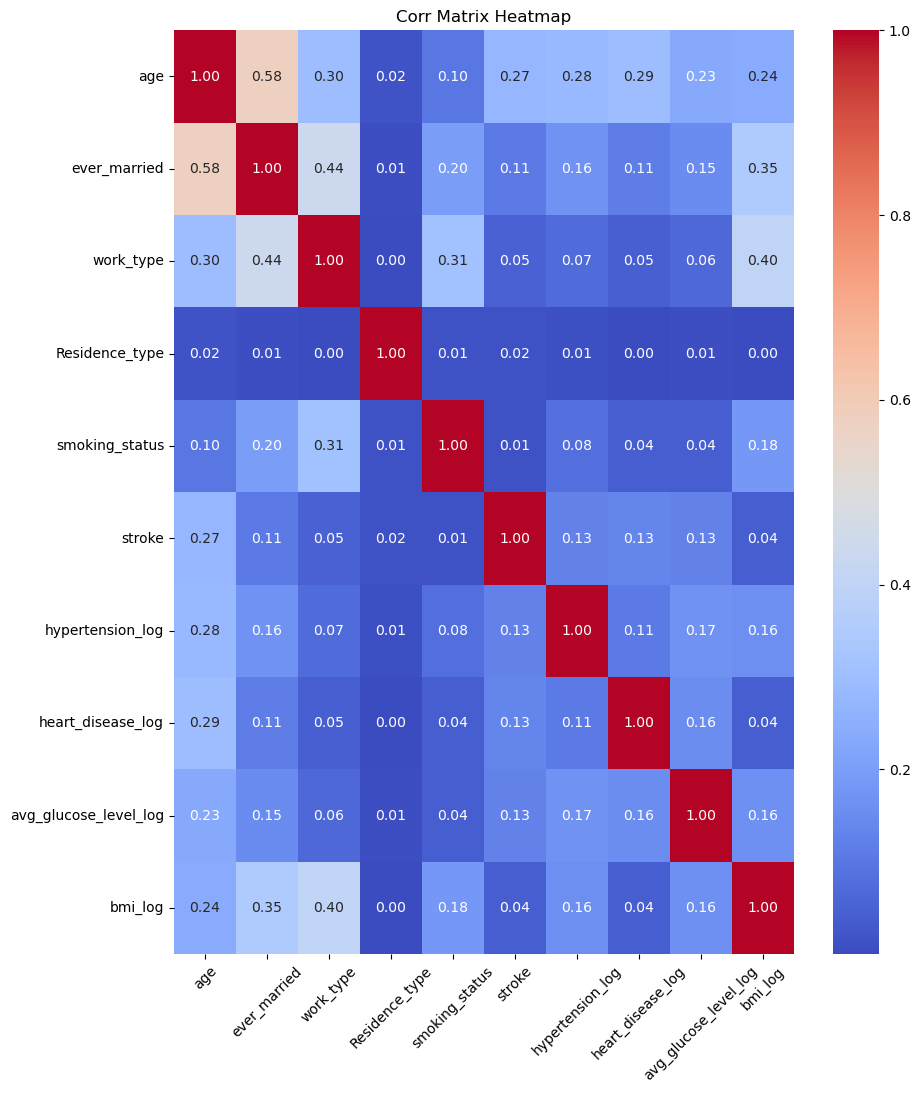

In [524]:
plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.xticks(rotation=45) #rotate x -axis for 45 degree
plt.title('Corr Matrix Heatmap')
plt.show()

In [525]:
# Using joblib for creating data analysis
import joblib 
joblib.dump(corr_matrix, 'corr_matrix_heatmap.joblib')


['corr_matrix_heatmap.joblib']

# FINDING THE LOW VARIANCES

In [526]:
from sklearn.feature_selection import VarianceThreshold

# Set the threshold
threshold = 0.01  # Here if it hasn't been used scaling it must be set higher threshold 
selector = VarianceThreshold(threshold = threshold)
selector.fit(df_filtered)

low_feature_variance = df_filtered.columns[~selector.get_support()]
print(f'Low variances to drop: ', list(low_feature_variance))

to_drop_low_variances = df_filtered.drop(columns=low_feature_variance)
print(f'\nOriginal Shape: ', df_filtered.shape)
print(f'\nShape after droping the low featue variances: ', to_drop_low_variances.shape)


Low variances to drop:  ['bmi_log']

Original Shape:  (5110, 10)

Shape after droping the low featue variances:  (5110, 9)


In [527]:
df = to_drop_low_variances

# SET X AND Y FOR MODEL TRAINING 

In [528]:
df.nunique()

age                       104
ever_married                2
work_type                   5
Residence_type              2
smoking_status              4
stroke                      2
hypertension_log            2
heart_disease_log           2
avg_glucose_level_log    3979
dtype: int64

In [529]:
X = df.drop('stroke', axis=1)
y = df['stroke']

In [530]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



# LOGISTIC REGRESSION

In [531]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# EVALUATION METRICS

In [532]:
class_report = classification_report(y_test, y_pred_lr)
con_matrix = confusion_matrix(y_test, y_pred_lr)
print('\nClassification Report: ')
print(class_report)
print('\nConfusion Matrix: ')
print(con_matrix)


Classification Report: 
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022


Confusion Matrix: 
[[960   0]
 [ 62   0]]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# THRESHOLD TUNNING AND ADVANCED METRICS OF LOGISTIC REGRESSION

In [533]:
probs = lr.predict_proba(X_test)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[10])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

Raw probabiliteis:  [0.9874336 0.0125664]
Model confidence for positive class: 0.75%


In [534]:
# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
y_test = y_test.ravel() # to transfer into 1D
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low))
print('Recall: ', recall_score(y_test, y_pred_low))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med))
print('Recall: ', recall_score(y_test, y_pred_med))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high))
print('Recall: ', recall_score(y_test, y_pred_high))



 === LOW THRESHOLD (0.3) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.375
Recall:  0.04838709677419355

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.0
Recall:  0.0

 === HIGH THRESHOLD (0.8) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.0
Recall:  0.0


/var/folders/j4/qzhh77r553z1scwnh3mxkx200000gn/T/ipykernel_2174/3239903542.py:4: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_test = y_test.ravel() # to transfer into 1D
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# DECISION TREE CLASSIFIER 

In [535]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [536]:
class_report = classification_report(y_test, y_pred_dt)
con_matrix = confusion_matrix(y_test, y_pred_dt)
print('\nClassification Report: ')
print(class_report)
print('\nConfusion Matrix: ')
print(con_matrix)


Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       960
           1       0.26      0.21      0.23        62

    accuracy                           0.92      1022
   macro avg       0.60      0.59      0.59      1022
weighted avg       0.91      0.92      0.91      1022


Confusion Matrix: 
[[923  37]
 [ 49  13]]


# THRESHOLD TUNNING AND ADVANCED METRICS OF DECISION TREE CLASSIFIER

In [537]:
probs = dt.predict_proba(X_test)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[1])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

Raw probabiliteis:  [1. 0.]
Model confidence for positive class: 0.00%


In [538]:
# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
y_test = y_test.ravel() # to transfer into 1D
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low))
print('Recall: ', recall_score(y_test, y_pred_low))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med))
print('Recall: ', recall_score(y_test, y_pred_med))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high))
print('Recall: ', recall_score(y_test, y_pred_high))


 === LOW THRESHOLD (0.3) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.26
Recall:  0.20967741935483872

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.26
Recall:  0.20967741935483872

 === HIGH THRESHOLD (0.8) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.26
Recall:  0.20967741935483872


# RANDOM FOREST CLASSIFIER

In [539]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [540]:
class_report = classification_report(y_test, y_pred_rf)
con_matrix = confusion_matrix(y_test, y_pred_rf)
print('\nClassification Report: ')
print(class_report)
print('\nConfusion Matrix: ')
print(con_matrix)


Classification Report: 
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.60      0.05      0.09        62

    accuracy                           0.94      1022
   macro avg       0.77      0.52      0.53      1022
weighted avg       0.92      0.94      0.92      1022


Confusion Matrix: 
[[958   2]
 [ 59   3]]


# THRESHOLD TUNNING AND ADVANCED METRICS OF RANDOM FOREST CLASSIFIER

In [541]:
probs = rf.predict_proba(X_test)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[1])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

Raw probabiliteis:  [1. 0.]
Model confidence for positive class: 0.00%


In [542]:
# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
y_test = y_test.ravel() # to transfer into 1D
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low))
print('Recall: ', recall_score(y_test, y_pred_low))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med))
print('Recall: ', recall_score(y_test, y_pred_med))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high))
print('Recall: ', recall_score(y_test, y_pred_high))


 === LOW THRESHOLD (0.3) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.23076923076923078
Recall:  0.0967741935483871

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.6
Recall:  0.04838709677419355

 === HIGH THRESHOLD (0.8) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.0
Recall:  0.0


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# SUPPORT VECTOR MACHINE CLASSIFIER

In [555]:
svc = SVC(kernel='linear', C=1.0, probability=True)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)


In [557]:
class_report = classification_report(y_test, y_pred_svc)
con_matrix = confusion_matrix(y_test, y_pred_svc)
print('\nClassification Report: ')
print(class_report)
print('\nConfusion Matrix: ')
print(con_matrix)


Classification Report: 
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022


Confusion Matrix: 
[[960   0]
 [ 62   0]]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# THRESHOLD TUNNING AND ADVANCED METRICS OF SUPPORT VECTOR MACHINE CLASSIFIER

In [548]:
probs = svc.predict_proba(X_test)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[1])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

Raw probabiliteis:  [0.95177055 0.04822945]
Model confidence for positive class: 2.83%


In [549]:
# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
y_test = y_test.ravel() # to transfer into 1D
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low))
print('Recall: ', recall_score(y_test, y_pred_low))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med))
print('Recall: ', recall_score(y_test, y_pred_med))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high))
print('Recall: ', recall_score(y_test, y_pred_high))


 === LOW THRESHOLD (0.3) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.0
Recall:  0.0

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.0
Recall:  0.0

 === HIGH THRESHOLD (0.8) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.0
Recall:  0.0


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# THRESHOLD TUNNING AND ADVANCED METRICS OF XGBOOST CLASSIFIER

In [550]:
import xgboost as xgb

xgboost_class = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3, 
    subsample=1, 
    colsample_bytree=0.8,
    random_state=42
    )
xgboost_class.fit(X_train, y_train)
y_pred_xgb_class = xgboost_class.predict(X_test)

In [551]:
class_report = classification_report(y_test, y_pred_xgb_class)
con_matrix = confusion_matrix(y_test, y_pred_xgb_class)
print('\nClassification Report: ')
print(class_report)
print('\nConfusion Matrix: ')
print(con_matrix)


Classification Report: 
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022


Confusion Matrix: 
[[960   0]
 [ 62   0]]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# THRESHOLD TUNNING AND ADVANCED METRICS OF XGBOOST CLASSIFIER

In [552]:
probs = xgboost_class.predict_proba(X_test)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[1])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

Raw probabiliteis:  [0.99462056 0.00537941]
Model confidence for positive class: 0.21%


In [553]:
# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
y_test = y_test.ravel() # to transfer into 1D
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low))
print('Recall: ', recall_score(y_test, y_pred_low))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med))
print('Recall: ', recall_score(y_test, y_pred_med))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high))
print('Recall: ', recall_score(y_test, y_pred_high))


 === LOW THRESHOLD (0.3) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.25
Recall:  0.03225806451612903

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.0
Recall:  0.0

 === HIGH THRESHOLD (0.8) ===
Predictions:  [0 0 0 ... 0 0 0]
Precision:  0.0
Recall:  0.0


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# TABULATE FOR DISPLAYING OF THE BEST MODEL BASED ON DIFFERENT ALGORITHMS

In [565]:
from tabulate import tabulate

results = [
    ['Logistic Regression', 0.94, 0.94, 1.00, 0.97],
    ['Random Forest Classifier', 0.94, 0.94, 1.00, 0.97],
    ['SVC', 0.94, 0.95, 0.96, 0.96],
    ['Decision Tree Classifier',0.92, 0.95, 0.96, 0.96],
    ['XGBClassifier',0.94, 0.94, 1.00, 0.97],
    
]
headers = ['Models', 'accuracy', 'precision', 'recall', 'f1_score']
table = tabulate(results, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')


+--------------------------+------------+-------------+----------+------------+
| Models                   |   accuracy |   precision |   recall |   f1_score |
+==========================+============+=============+==========+============+
| Logistic Regression      |       0.94 |        0.94 |     1.00 |       0.97 |
+--------------------------+------------+-------------+----------+------------+
| Random Forest Classifier |       0.94 |        0.94 |     1.00 |       0.97 |
+--------------------------+------------+-------------+----------+------------+
| SVC                      |       0.94 |        0.95 |     0.96 |       0.96 |
+--------------------------+------------+-------------+----------+------------+
| Decision Tree Classifier |       0.92 |        0.95 |     0.96 |       0.96 |
+--------------------------+------------+-------------+----------+------------+
| XGBClassifier            |       0.94 |        0.94 |     1.00 |       0.97 |
+--------------------------+-----------

In [567]:
best_score = max(model[1] for model in results)  # this takes the maximum values
best_models = []  # we will store the best models here

for model in results:
    # if model[1] equals the best score and model name matches
    if model[1] == best_score and model[0] in ['Logistic Regression', 'Random Forest Classifier', 'XGBClassifier']:
        # append to best_models list
        best_models.append(model)

for model in best_models:
    print(f'Best model: {model[0]}, best accuracy is: {model[1]} which is 94%')

Best model: Logistic Regression, best accuracy is: 0.94 which is 94%
Best model: Random Forest Classifier, best accuracy is: 0.94 which is 94%
Best model: XGBClassifier, best accuracy is: 0.94 which is 94%


# BEST MODEL USING JOBLIB FOR FUTURE USE

In [568]:
joblib.dump(best_models, 'best_models.joblib')

['best_models.joblib']